In [1]:
# LONDON UNDERGROUND NETWORK VULNERABILITY ANALYSIS

import pandas as pd
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

tube_con = pd.read_csv('london_tube_connections.csv')
tube_st = pd.read_csv('london_tube_stations.csv')
entry_counts = pd.read_csv('AC2022_AnnualisedEntryExit.csv')
lines = pd.read_csv('london_tube_lines.csv')

print(tube_con.head())
print(tube_st.head())
print(entry_counts.head())
print(lines.head())


# CLEAN DATA


print(tube_con.isnull().sum())
print(tube_st.isnull().sum())
print(entry_counts.isnull().sum())
print(lines.isnull().sum())

# Drop unnecessary columns

if 'display_name' in tube_st.columns:
    tube_st.drop('display_name', axis=1, inplace=True)

if 'stripe' in lines.columns:
    lines.drop('stripe', axis=1, inplace=True)



   station1  station2  line  time
0        11       163     1     1
1        11       212     1     2
2        49        87     1     1
3        49       197     1     2
4        82       163     1     2
   id  latitude  longitude          name       display_name  zone  \
0   1   51.5028    -0.2801    Acton Town    Acton<br />Town   3.0   
1   2   51.5143    -0.0755       Aldgate                NaN   1.0   
2   3   51.5154    -0.0726  Aldgate East  Aldgate<br />East   1.0   
3   4   51.5107    -0.0130    All Saints    All<br />Saints   2.0   
4   5   51.5407    -0.2997      Alperton                NaN   4.0   

   total_lines  rail  
0            2     0  
1            2     0  
2            2     0  
3            1     0  
4            1     0  
  Mode  MNLC  MASC       Station            Coverage    Source Entries_Monday  \
0   LU   500  ACTu    Acton Town  Station entry/exit  Gateline          7,305   
1   LU   502  ALDu       Aldgate  Station entry/exit  Gateline         10,033   


In [2]:
# CONVERT ENTRY COLUMNS TO NUMERIC


entry_cols = [

    'Entries_Monday',
    'Entries_midweek',
    'Entries_Friday',
    'Entries_Saturday',
    'Entries_Sunday',
    'Exits_Monday',
    'Exits_midweek',
    'Exits_Friday',
    'Exits_Saturday',
    'Exits_Sunday',
    'En/Ex_weekly',
    'En/Ex_12week',
    'En/Ex_annual'
]

for col in entry_cols:

    entry_counts[col] = (

        entry_counts[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)

    )

print(entry_counts.dtypes)


# CREATE TOTAL ANNUAL ENTRIES


entry_counts['total_entries'] = (

    (
        entry_counts['Entries_Monday'] +
        entry_counts['Entries_midweek'] +
        entry_counts['Entries_Friday'] +
        entry_counts['Entries_Saturday'] +
        entry_counts['Entries_Sunday']
    ) * 52

)

Mode                 object
MNLC                  int64
MASC                 object
Station              object
Coverage             object
Source               object
Entries_Monday      float64
Entries_midweek     float64
Entries_Friday      float64
Entries_Saturday    float64
Entries_Sunday      float64
Exits_Monday        float64
Exits_midweek       float64
Exits_Friday        float64
Exits_Saturday      float64
Exits_Sunday        float64
En/Ex_weekly        float64
En/Ex_12week        float64
En/Ex_annual        float64
dtype: object


In [3]:

# CREATE STATION DATAFRAME


tube_stations = tube_st.join(

    entry_counts,

    lsuffix='_left',

    rsuffix='_right'

)

tube_stations_final = tube_stations[[

    'id',
    'name',
    'latitude',
    'longitude',
    'zone',
    'total_lines',
    'total_entries'

]]

# Replace zeros with mean

tube_stations_final['total_entries'] = (

    tube_stations_final['total_entries']
    .replace(0, tube_stations_final['total_entries'].mean())

)

print(tube_stations_final.head())

   id          name  latitude  longitude  zone  total_lines  total_entries
0   1    Acton Town   51.5028    -0.2801   3.0            2      1837940.0
1   2       Aldgate   51.5143    -0.0755   1.0            2      2249780.0
2   3  Aldgate East   51.5154    -0.0726   1.0            2      4019496.0
3   4    All Saints   51.5107    -0.0130   2.0            1       853372.0
4   5      Alperton   51.5407    -0.2997   4.0            1       604188.0


C:\Users\chrys\AppData\Local\Temp\ipykernel_12632\1218786860.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tube_stations_final['total_entries'] = (


In [4]:

# MERGE CONNECTIONS WITH STATIONS


tube_con1 = pd.merge(

    tube_con,
    tube_stations_final,

    left_on='station1',
    right_on='id',

    how='inner'

)

crd = list(zip(

    tube_stations_final['longitude'],
    tube_stations_final['latitude']

))

pos = dict(zip(

    tube_stations_final['id'],
    crd

))


# CREATE GRAPH


g = nx.Graph()

for connection_id, connection in tube_con1.iterrows():

    station1 = tube_stations_final[
        tube_stations_final.id == connection['station1']
    ].to_dict('records')[0]

    station2 = tube_stations_final[
        tube_stations_final.id == connection['station2']
    ].to_dict('records')[0]

    g.add_node(station1['id'])
    g.add_node(station2['id'])

    nx.set_node_attributes(g, {

        station1['id']: station1,
        station2['id']: station2

    })

    g.add_edge(

        station1['id'],
        station2['id'],

        weight=connection['total_entries'],
        line_id=connection['line']

    )

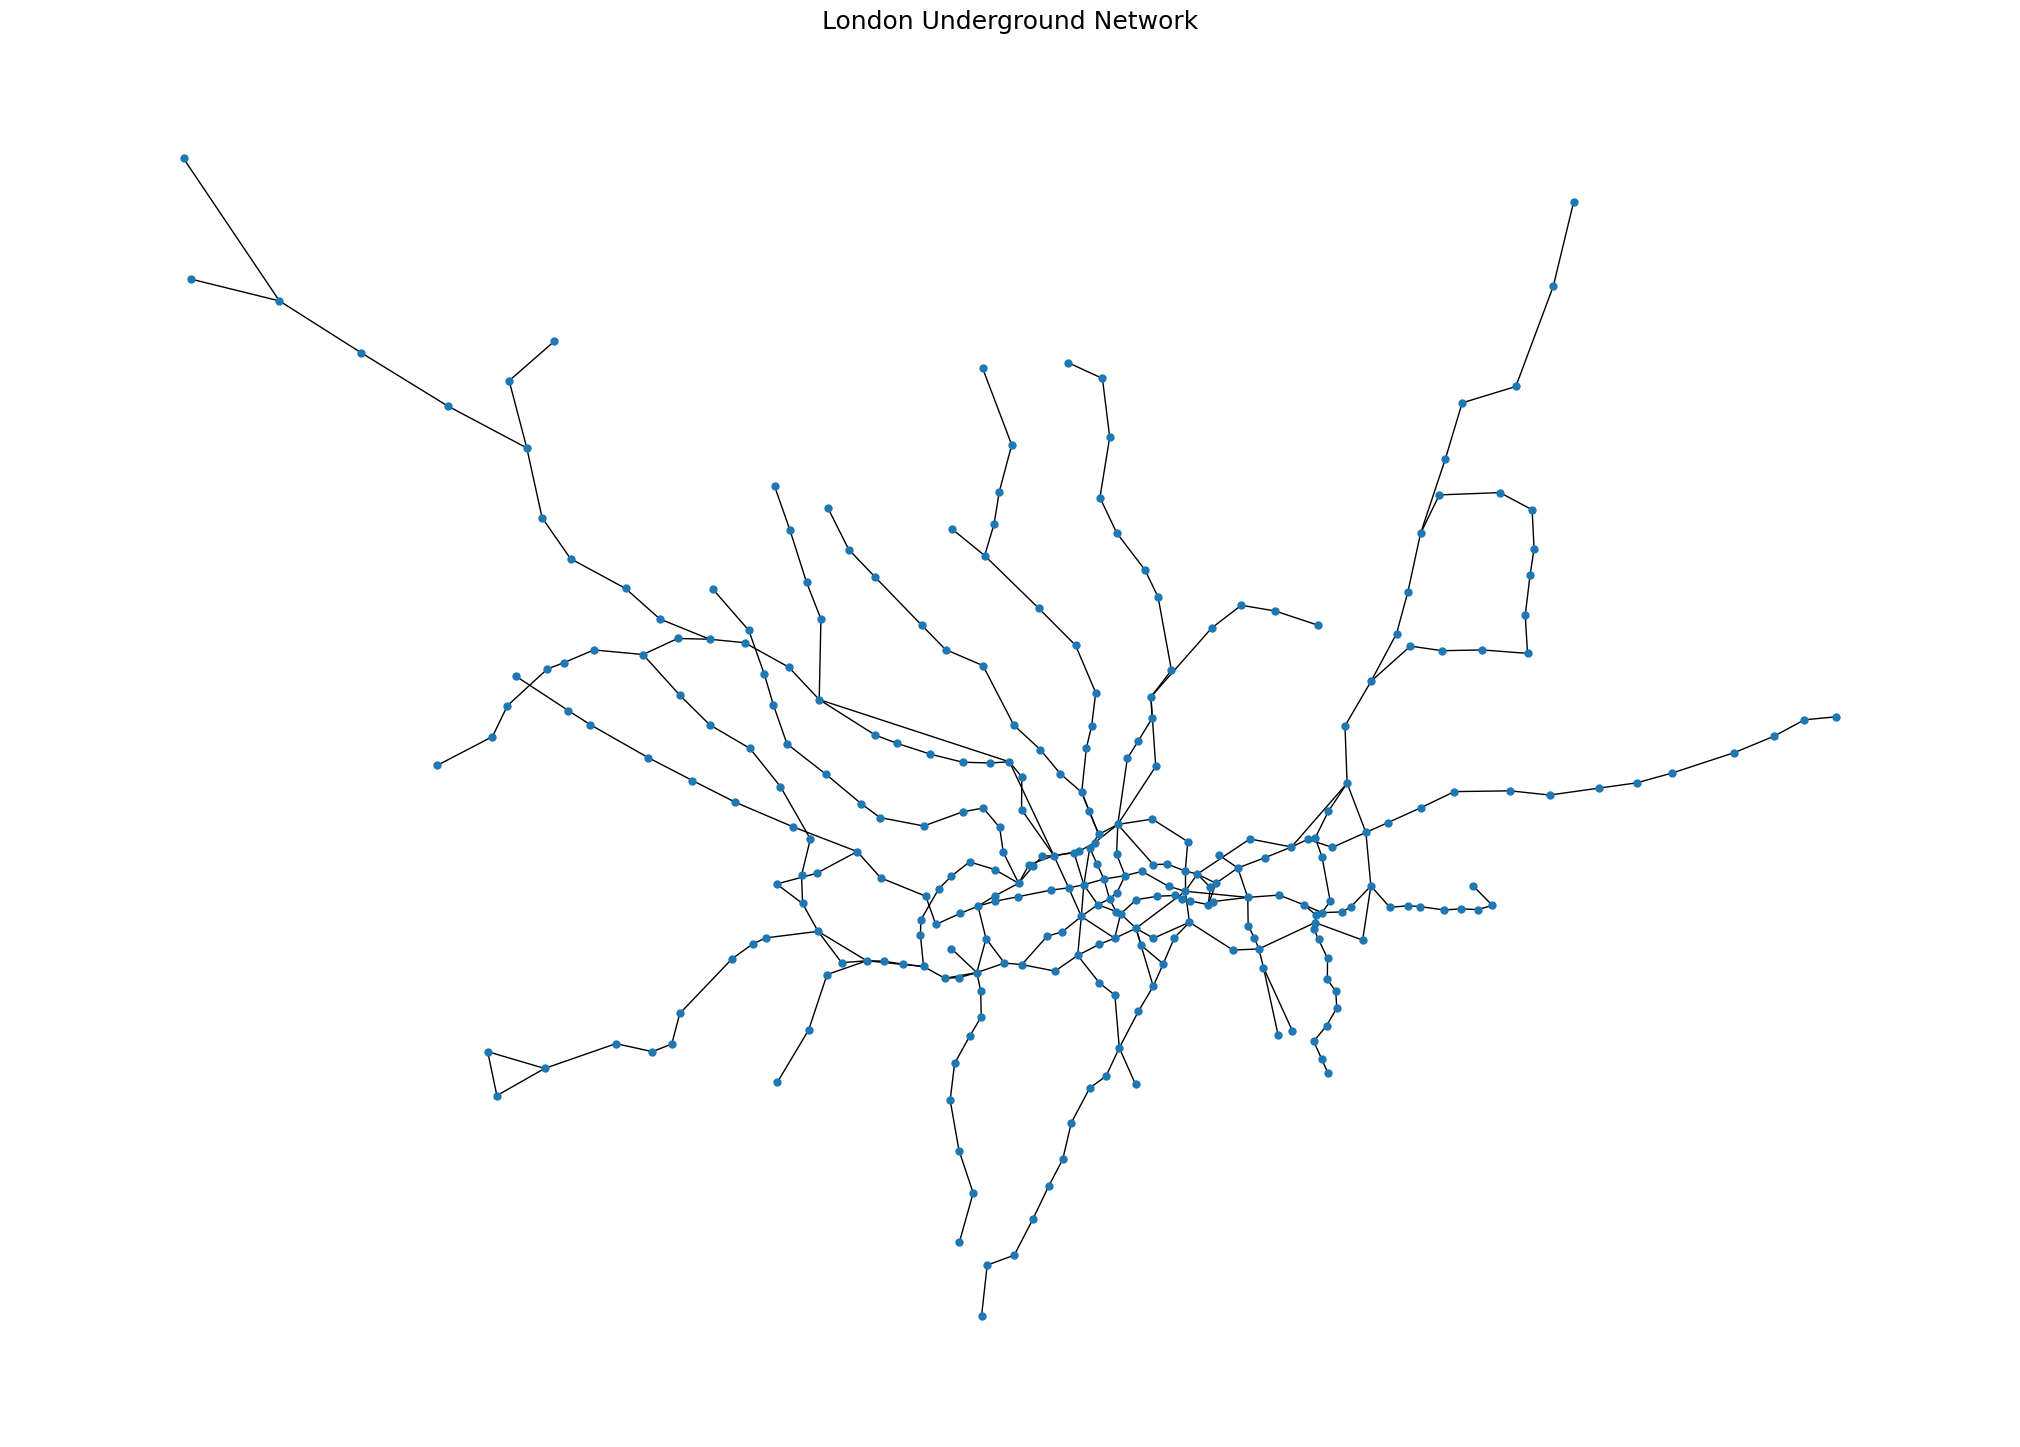

In [6]:
plt.figure(figsize=(20, 14))

nx.draw(

    g,
    pos,

    node_size=25,

    width=1,

    with_labels=False

)

plt.title(

    'London Underground Network',

    fontsize=18

)

plt.show()

                 name  degree  betw_centrality  degree_centrality  \
115      Earl's Court       6          0.38100            0.01993   
17           Waterloo       6          0.36802            0.01993   
103  South Kensington       3          0.33996            0.00997   
101   Gloucester Road       3          0.33739            0.00997   
19        Westminster       4          0.33420            0.01329   
179      Canada Water       4          0.31528            0.01329   
41      London Bridge       4          0.30910            0.01329   
190        Bermondsey       2          0.30605            0.00664   
203         Southwark       2          0.30585            0.00664   
49         Green Park       6          0.29110            0.01993   

     eigenvector_centrality  
115                 0.00649  
17                  0.19024  
103                 0.02480  
101                 0.00988  
19                  0.22591  
179                 0.00837  
41                  0.06402  


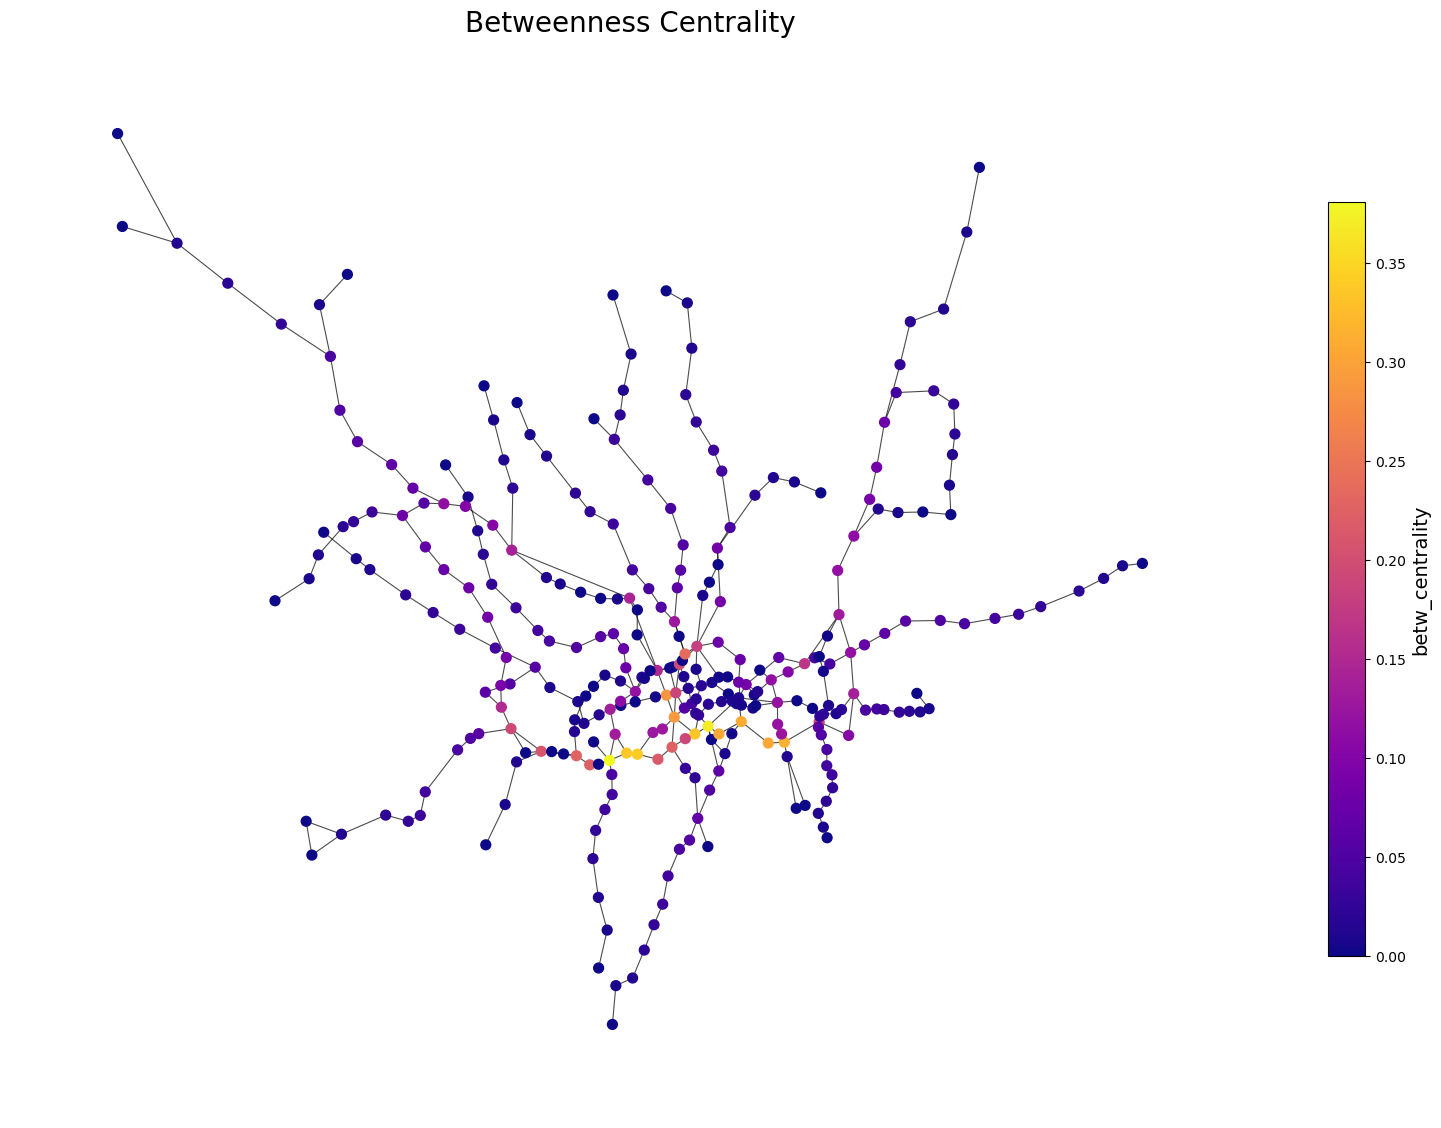

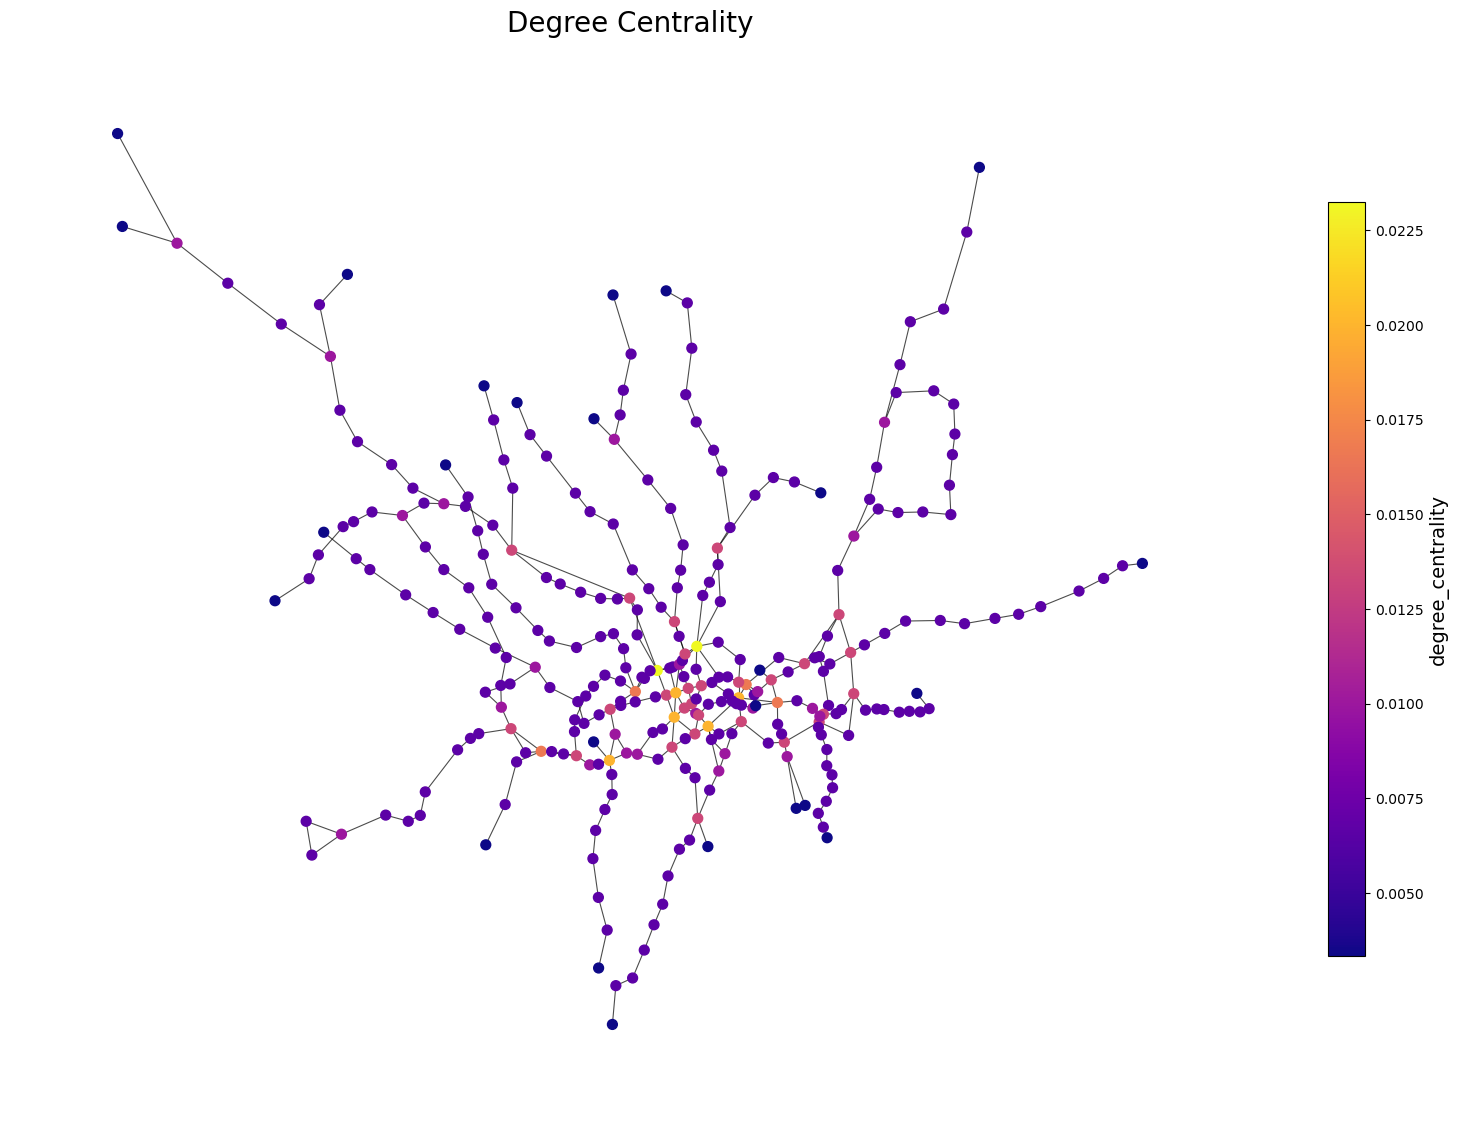

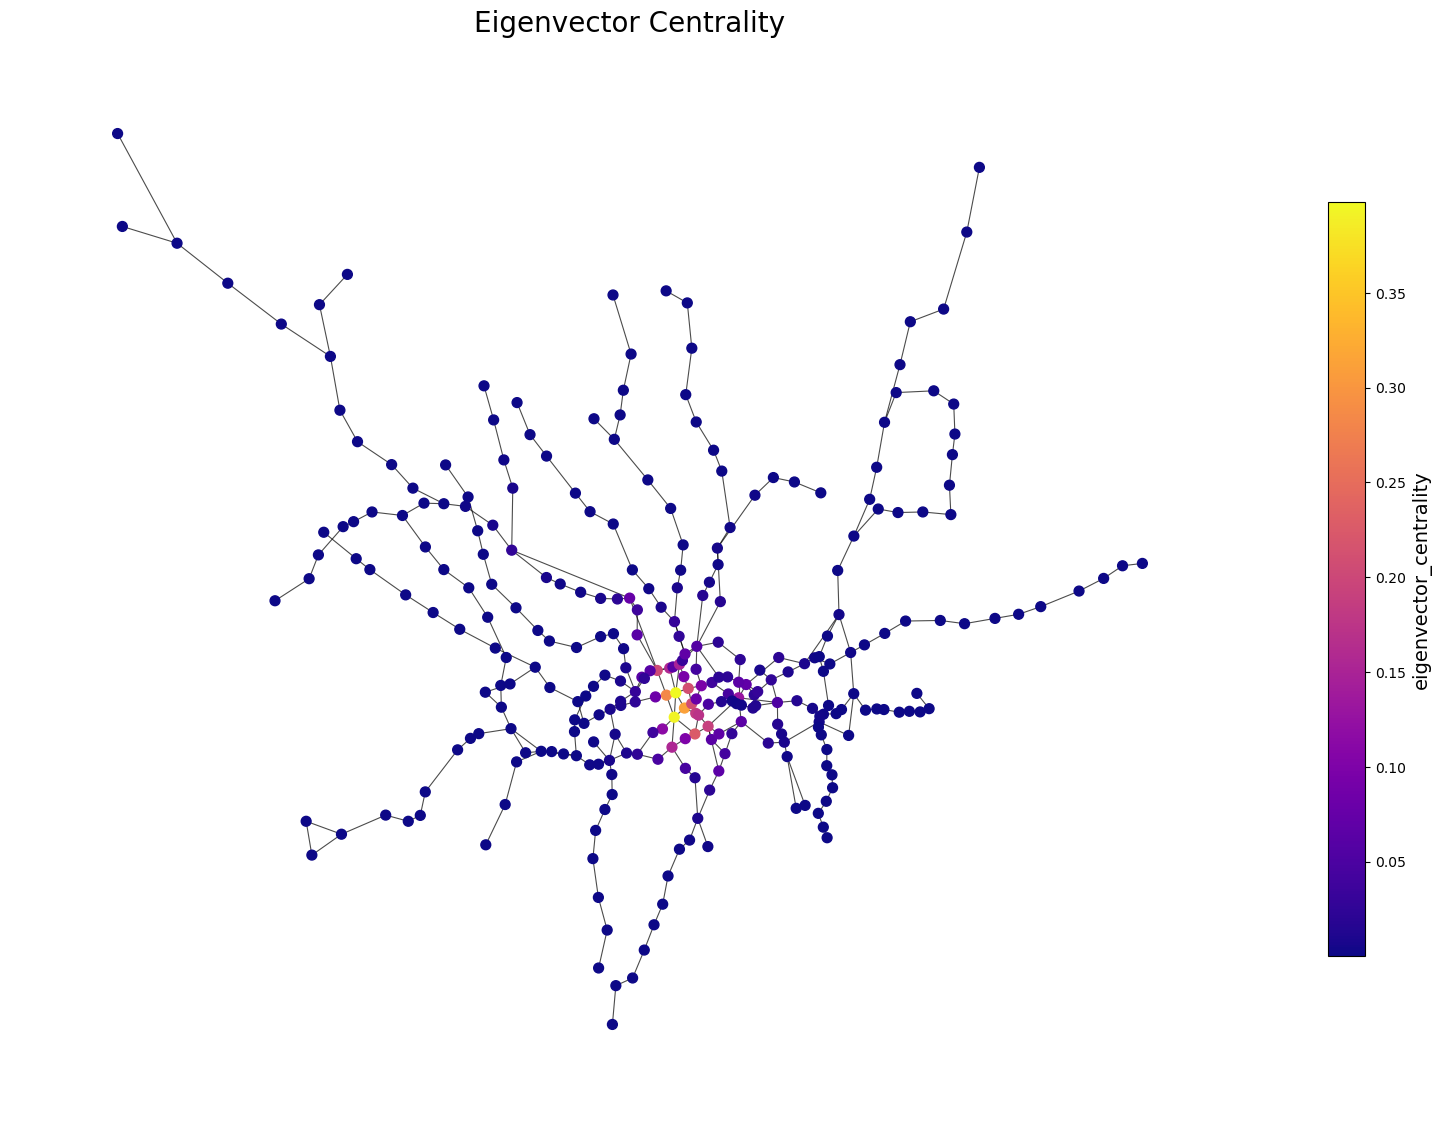

In [8]:

# CENTRALITY ANALYSIS


nx.set_node_attributes(

    g,

    nx.betweenness_centrality(
        g,
        weight='weight'
    ),

    'betw_centrality'
)

nx.set_node_attributes(

    g,

    nx.degree_centrality(g),

    'degree_centrality'
)

nx.set_node_attributes(

    g,

    nx.eigenvector_centrality(
        g,
        max_iter=1000
    ),

    'eigenvector_centrality'
)


# CREATE RESULTS TABLE


degrees = [val for (node, val) in g.degree()]

names = [

    g.nodes[node]['name']
    for node in g

]

bcent = [

    round(g.nodes[node]['betw_centrality'], 5)
    for node in g

]

degree_centrality = [

    round(g.nodes[node]['degree_centrality'], 5)
    for node in g

]

eigenvector_centrality = [

    round(g.nodes[node]['eigenvector_centrality'], 5)
    for node in g

]

London_tube = pd.DataFrame({

    'name': names,
    'degree': degrees,
    'betw_centrality': bcent,
    'degree_centrality': degree_centrality,
    'eigenvector_centrality': eigenvector_centrality

})

London_tube = London_tube.sort_values(

    'betw_centrality',
    ascending=False

)

print(London_tube.head(10))

def plot_graph_color_nodes(

    g,
    title,
    colour_attr

):

   
    # EXTRACT CENTRALITY VALUES
   

    values = [

        g.nodes[node][colour_attr]

        for node in g.nodes
    ]


    fig, ax = plt.subplots(

        figsize=(20, 14)
    )

    nodes = nx.draw_networkx_nodes(

        g,

        pos,

        node_size=50,

        node_color=values,

        cmap='plasma',

        ax=ax
    )

    nx.draw_networkx_edges(

        g,

        pos,

        width=0.8,

        alpha=0.7,

        ax=ax
    )

    cbar = plt.colorbar(

        nodes,

        ax=ax,

        shrink=0.7
    )

    cbar.set_label(

        f"{colour_attr}",

        fontsize=14
    )

    plt.title(

        title,

        fontsize=20
    )

    plt.axis('off')

    plt.show()


# PLOT CENTRALITY MAPS

plot_graph_color_nodes(

    g,
    'Betweenness Centrality',
    'betw_centrality'
)

plot_graph_color_nodes(

    g,
    'Degree Centrality',
    'degree_centrality'
)

plot_graph_color_nodes(

    g,
    'Eigenvector Centrality',
    'eigenvector_centrality'
)

Randomly removed stations: 30


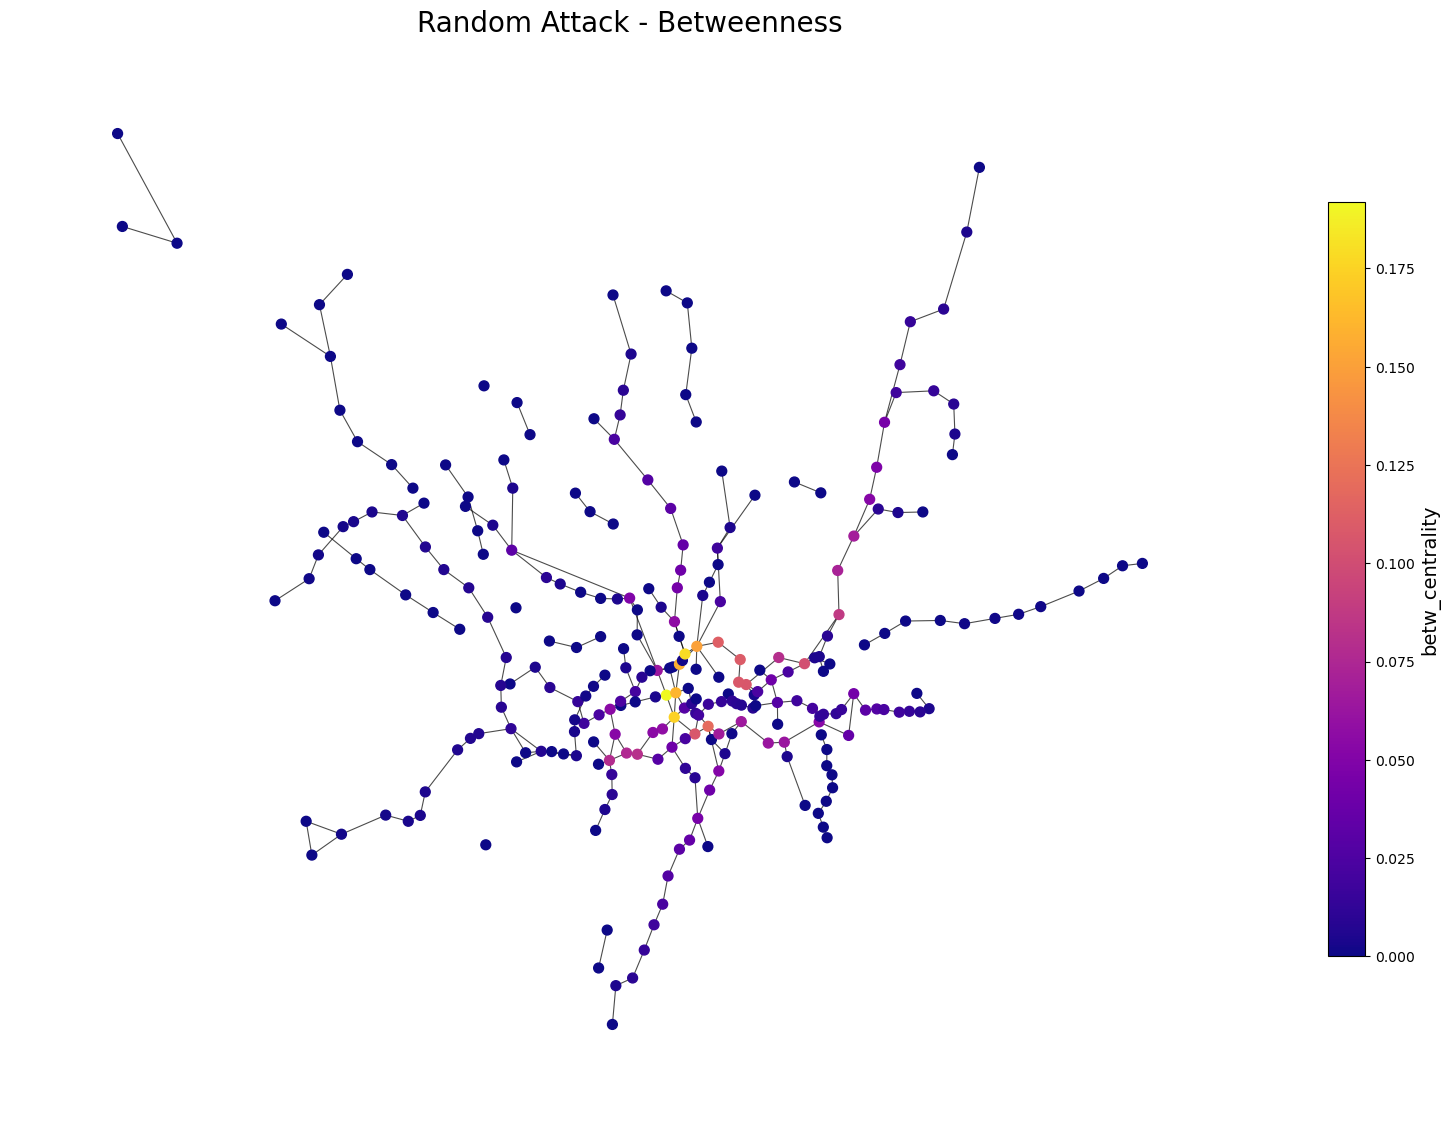

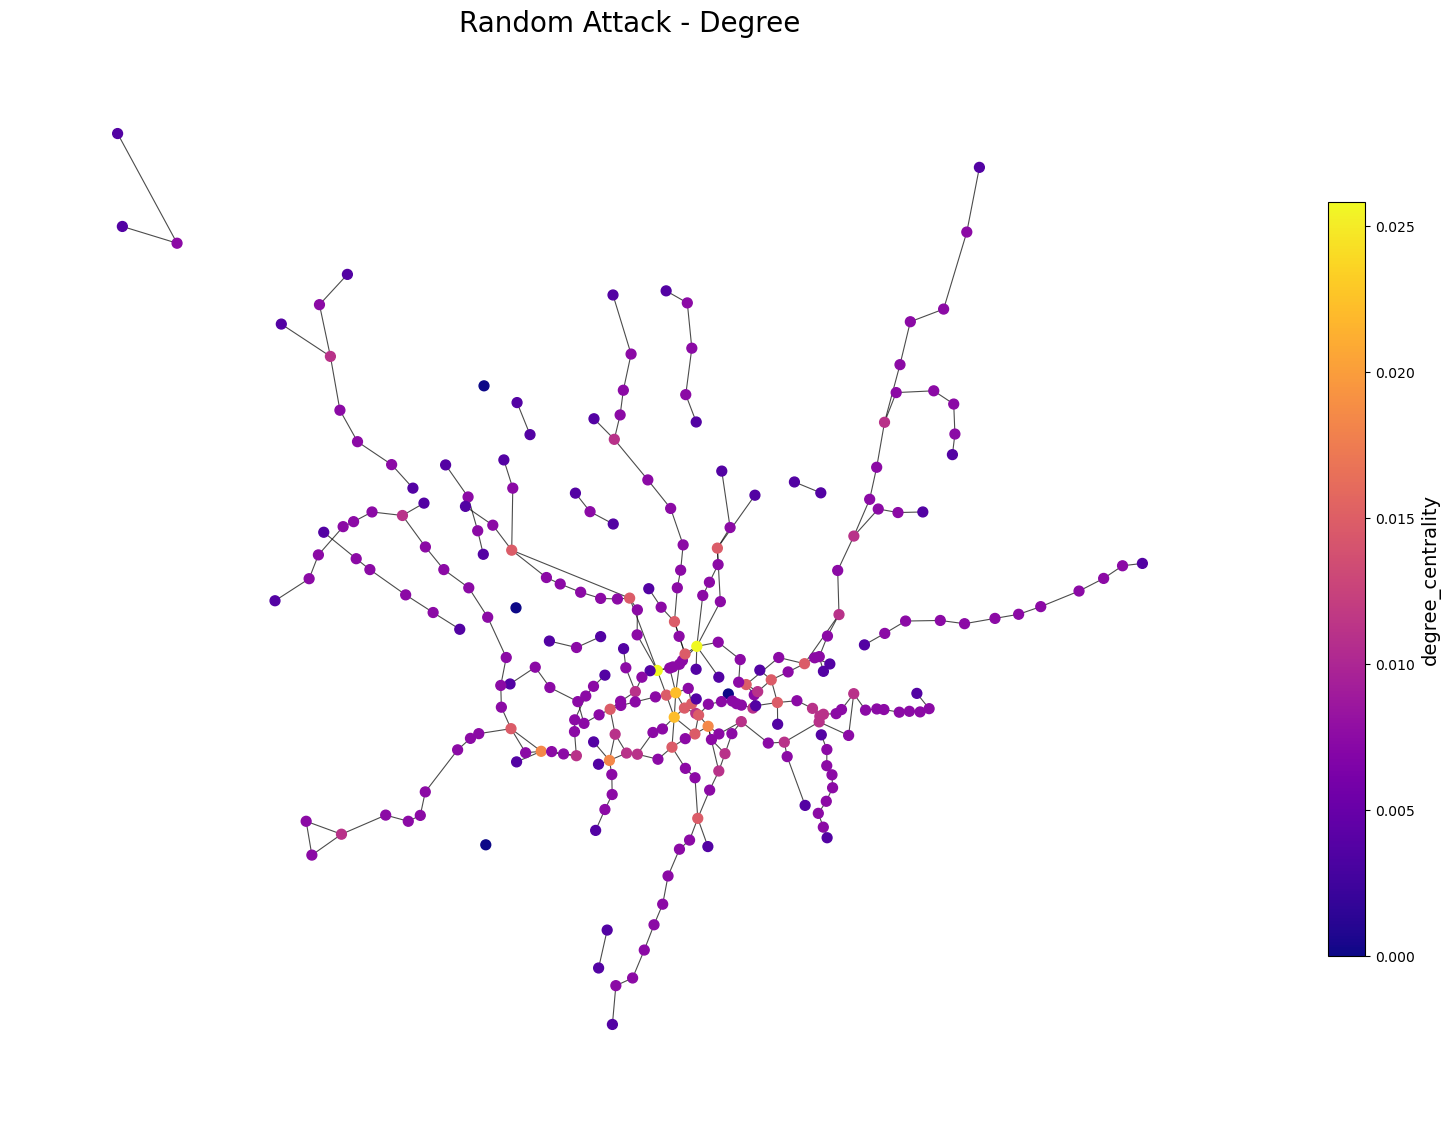

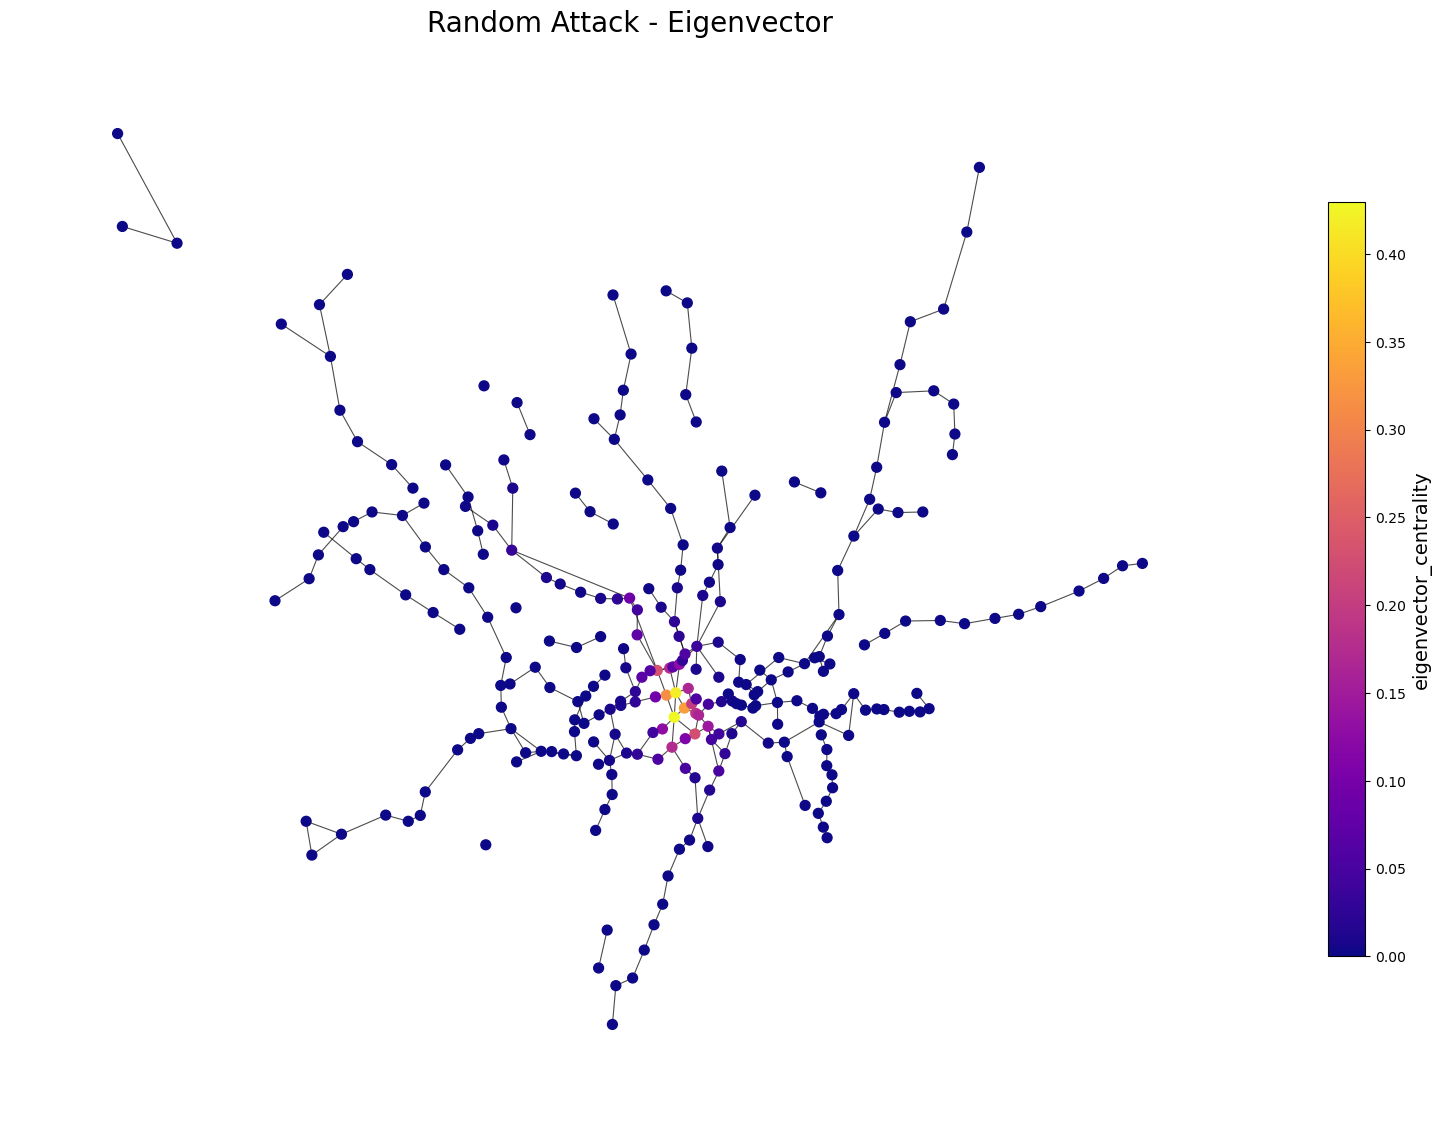

In [9]:

# RANDOM ATTACK

random.seed(42)

n_list = random.sample(

    sorted(g.nodes),

    30

)

g1 = g.copy()

g1.remove_nodes_from(n_list)

print(f"Randomly removed stations: {len(n_list)}")


nx.set_node_attributes(

    g1,

    nx.betweenness_centrality(
        g1,
        weight='weight'
    ),

    'betw_centrality'
)

nx.set_node_attributes(

    g1,

    nx.degree_centrality(g1),

    'degree_centrality'
)

nx.set_node_attributes(

    g1,

    nx.eigenvector_centrality(
        g1,
        max_iter=1000
    ),

    'eigenvector_centrality'
)


plot_graph_color_nodes(

    g1,
    'Random Attack - Betweenness',
    'betw_centrality'
)

plot_graph_color_nodes(

    g1,
    'Random Attack - Degree',
    'degree_centrality'
)

plot_graph_color_nodes(

    g1,
    'Random Attack - Eigenvector',
    'eigenvector_centrality'
)

Targeted removed stations: 30


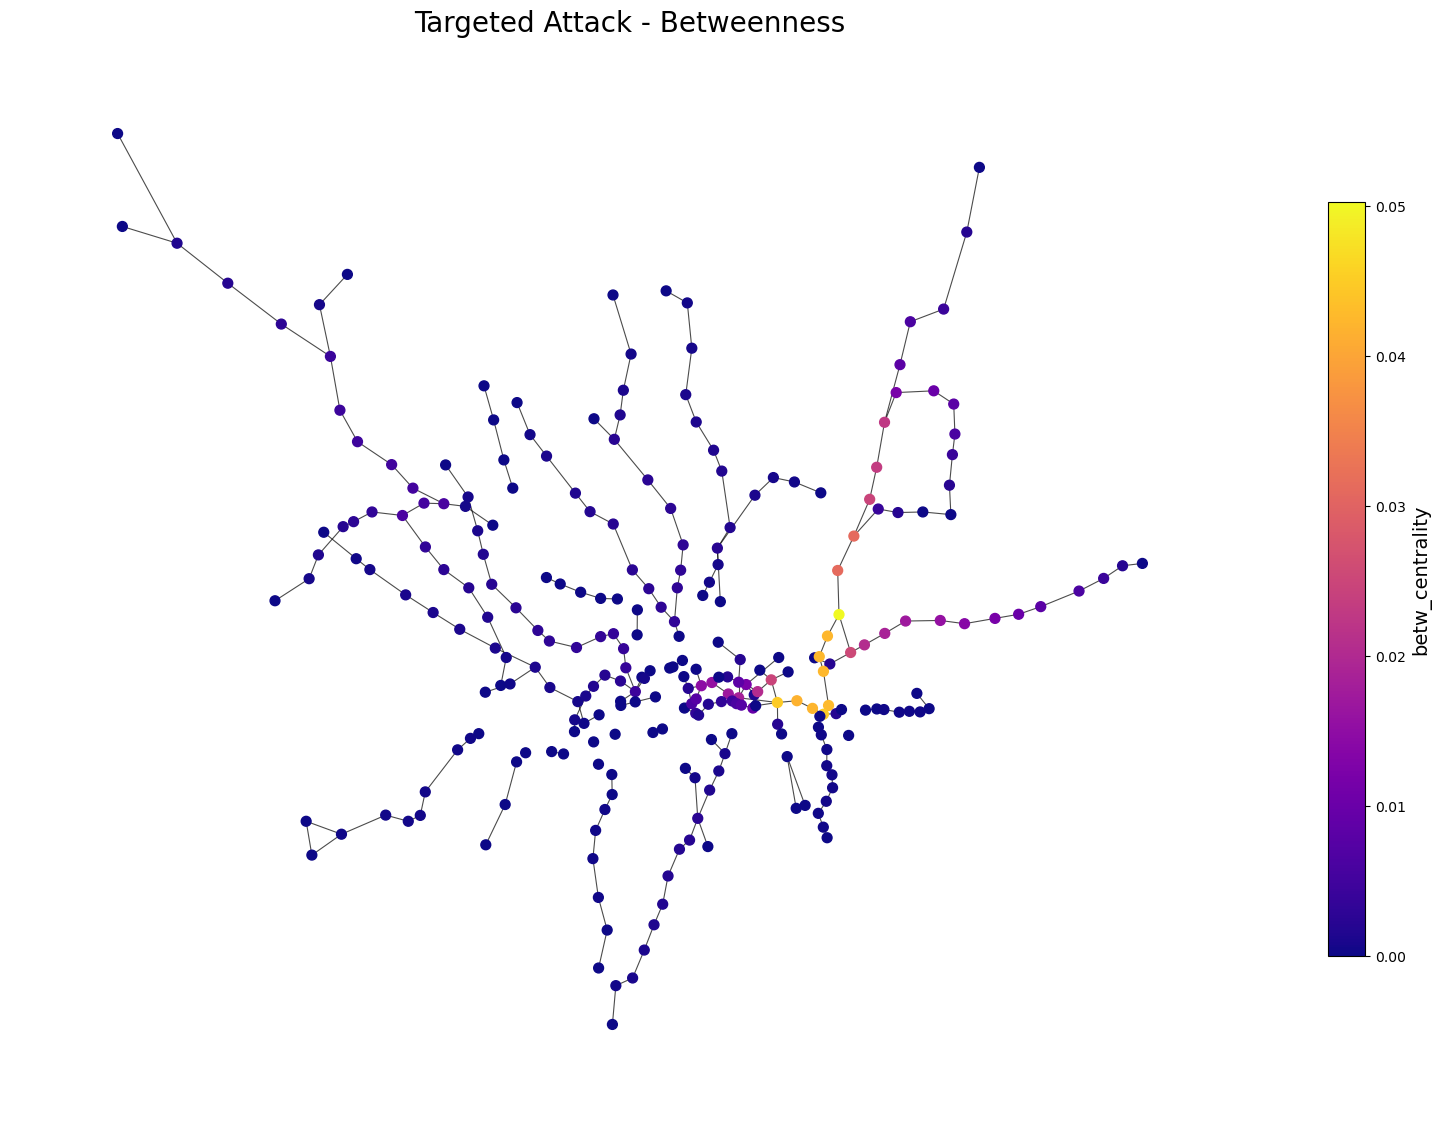

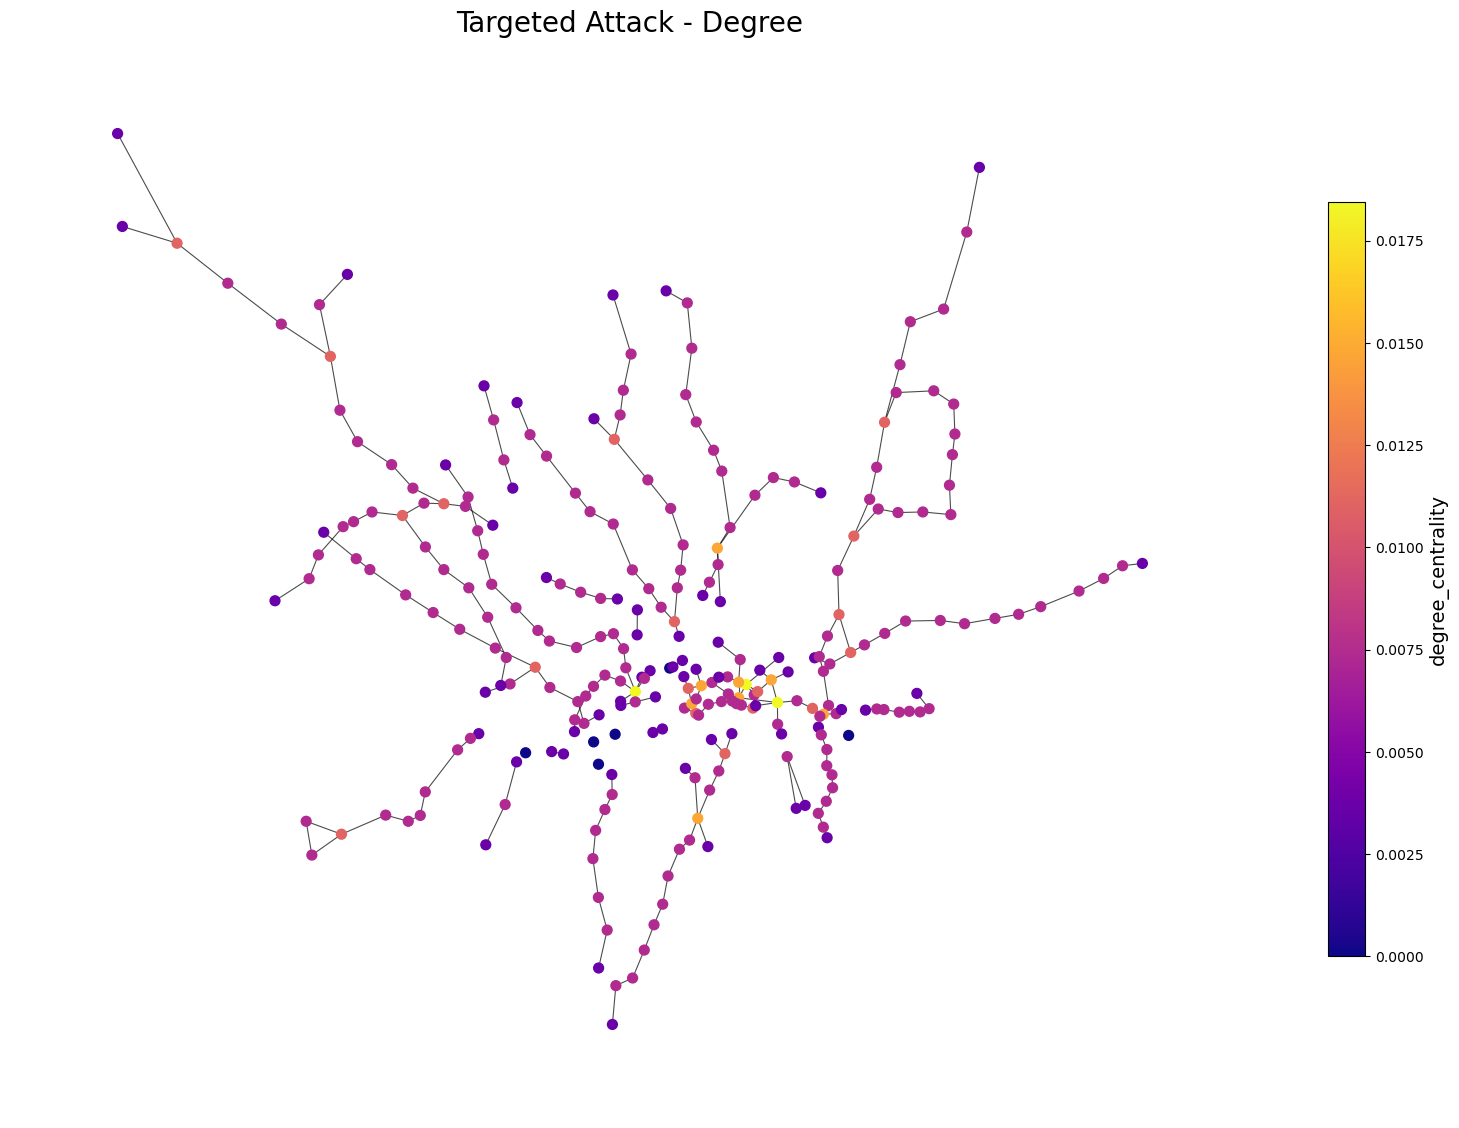

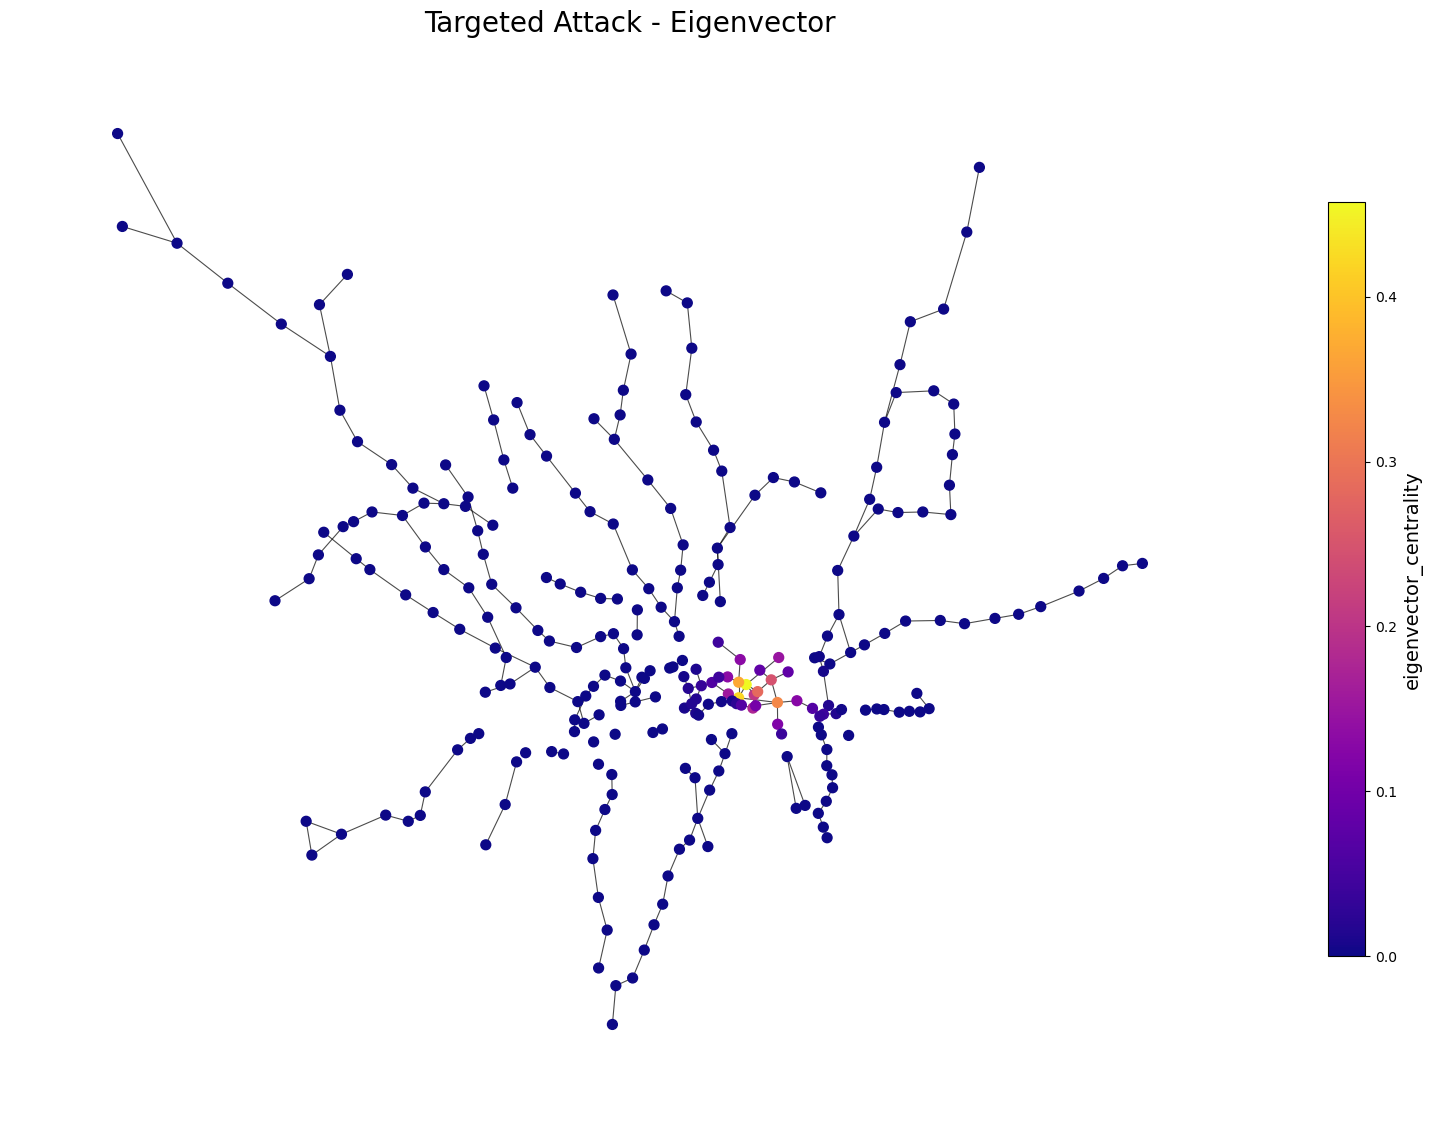

In [10]:

# TARGETED ATTACK
# Remove busiest stations

top_stations = London_tube.sort_values(

    'betw_centrality',
    ascending=False

).head(30)

nodes_remove2 = []

for node in g.nodes():

    station_name = g.nodes[node]['name']

    if station_name in top_stations['name'].values:

        nodes_remove2.append(node)

g2 = g.copy()

g2.remove_nodes_from(nodes_remove2)

print(f"Targeted removed stations: {len(nodes_remove2)}")


nx.set_node_attributes(

    g2,

    nx.betweenness_centrality(
        g2,
        weight='weight'
    ),

    'betw_centrality'
)

nx.set_node_attributes(

    g2,

    nx.degree_centrality(g2),

    'degree_centrality'
)

nx.set_node_attributes(

    g2,

    nx.eigenvector_centrality(
        g2,
        max_iter=1000
    ),

    'eigenvector_centrality'
)

plot_graph_color_nodes(

    g2,
    'Targeted Attack - Betweenness',
    'betw_centrality'
)

plot_graph_color_nodes(

    g2,
    'Targeted Attack - Degree',
    'degree_centrality'
)

plot_graph_color_nodes(

    g2,
    'Targeted Attack - Eigenvector',
    'eigenvector_centrality'
)


In [11]:

# NETWORK CONNECTIVITY ANALYSIS


print("\n==============================")
print("CONNECTED COMPONENTS")
print("==============================")

print(
    f"Original Network: "
    f"{nx.number_connected_components(g)} components"
)

print(
    f"Random Attack: "
    f"{nx.number_connected_components(g1)} components"
)

print(
    f"Targeted Attack: "
    f"{nx.number_connected_components(g2)} components"
)


# NETWORK DENSITY


print("\n==============================")
print("NETWORK DENSITY")
print("==============================")

print(
    f"Original Network Density: "
    f"{nx.density(g):.4f}"
)

print(
    f"Random Attack Density: "
    f"{nx.density(g1):.4f}"
)

print(
    f"Targeted Attack Density: "
    f"{nx.density(g2):.4f}"
)


# LARGEST CONNECTED COMPONENT


largest_cc_original = max(
    nx.connected_components(g),
    key=len
)

largest_cc_random = max(
    nx.connected_components(g1),
    key=len
)

largest_cc_target = max(
    nx.connected_components(g2),
    key=len
)

print("\n==============================")
print("LARGEST CONNECTED COMPONENT")
print("==============================")

print(
    f"Original: {len(largest_cc_original)} nodes"
)

print(
    f"Random Attack: {len(largest_cc_random)} nodes"
)

print(
    f"Targeted Attack: {len(largest_cc_target)} nodes"
)


London_tube.to_csv(

    'London_tube_centralities.csv',
    index=False

)

print("\nCentrality table saved successfully.")


CONNECTED COMPONENTS
Original Network: 1 components
Random Attack: 18 components
Targeted Attack: 26 components

NETWORK DENSITY
Original Network Density: 0.0077
Random Attack Density: 0.0077
Targeted Attack Density: 0.0069

LARGEST CONNECTED COMPONENT
Original: 302 nodes
Random Attack: 172 nodes
Targeted Attack: 80 nodes

Centrality table saved successfully.
